## **Course Task: Fine-Tuning vs. From-Scratch Training for Text Classification**

Author: Bartosz Hanc

### 1. Introduction

The objective of this assignment is to compare two distinct approaches to
training Transformer-based language models for full-text classification:
training a lightweight model entirely from scratch versus fine-tuning a
pre-trained Large Language Model (LLM).

We focus on the Polish Youth Slang Classification task. Classifying slang is a
particularly challenging NLP problem because it involves informal syntax,
intentional misspellings, neologisms, and context-dependent sentiment that often
defies standard grammatical rules. This report analyzes how a small,
custom-trained Encoder competes against HerBERT (a BERT model pre-trained on
massive Polish corpora) in terms of training stability, convergence speed, and
final classification metrics.

### 2. Dataset Description

The dataset consists of short text snippets containing Polish youth slang. 

* Training Set: 4337 examples.

* Validation Set: 542 examples.

* Test Set: 543 examples.

* Classes: 3 classes 0 = Negative sentiment, 1 = Neutral or ambiguous sentiment,
  2 = Positive sentiment

The texts are generally short but semantically dense e.g.

* `' - Masz może lejsy, Damian? - Mam, ale ci nie dam, Furto!                '`
* `'dobra nie spojleruje brawo gosciu - caly czas kibicowalam !!! a panowie -
  brawo za taka zagrywke na final'`

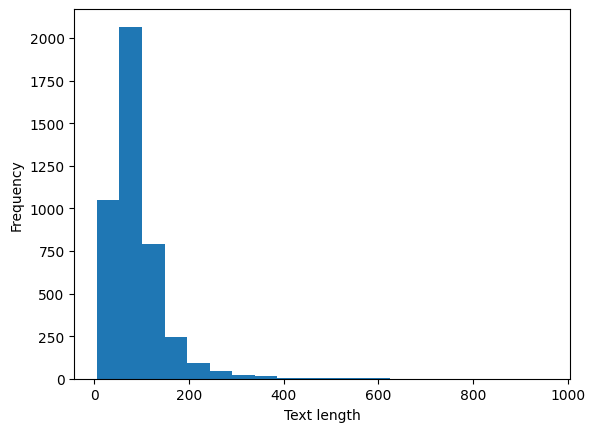

The classes are slightly unbalanced, however it is not extreme.

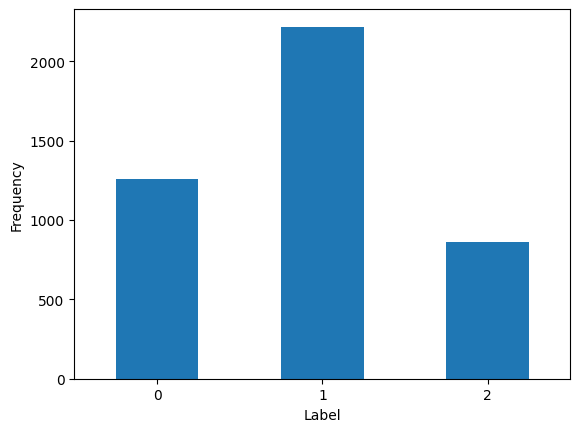

### Preprocessing

* For Fine-Tuning: We utilized the standard HerBERT tokenizer (BPE-based, vocab
  size 50,000) to leverage the pre-trained embeddings.

* For From-Scratch approach: We trained a custom BPE tokenizer specifically on
  the training corpus with a strictly reduced vocabulary size of 1000 tokens.
  This was a crucial design decision to prevent the small model's embedding
  layer from dominating the parameter count and causing immediate overfitting.

* All texts were padded/truncated to a maximum length of 128 tokens.

## 3. Model Architectures

### From-scratch approach

We designed a lightweight "Mini-Transformer" to be trainable on this relatively
small dataset. The architecture is a significantly scaled down encoder-only
transformer with following hyperparameters
- Embedding Dimension: 64
- Attention Heads: 8
- Layers: 2
- Dropout: 0.3 (Aggressive dropout to regularize)
- Classification Head: Masked Mean Pooling (averaging valid token embeddings)
  followed by a Linear layer
- Parameter Count: ~172K parameters.

### Fine-Tuned (HerBERT)

We selected HerBERT-base-cased, a robust BERT model pre-trained specifically on
the Polish language. It is a ~124M parameters model with a vocabulary size of
~50K tokens.

## 4. Training Results & Evaluation

Both models were trained using Cross-Entropy Loss on a single GPU - GTX 1660
Super with 6GB VRAM.

### From-Scratch Model Performance

The From-Scratch model struggled to generalize.

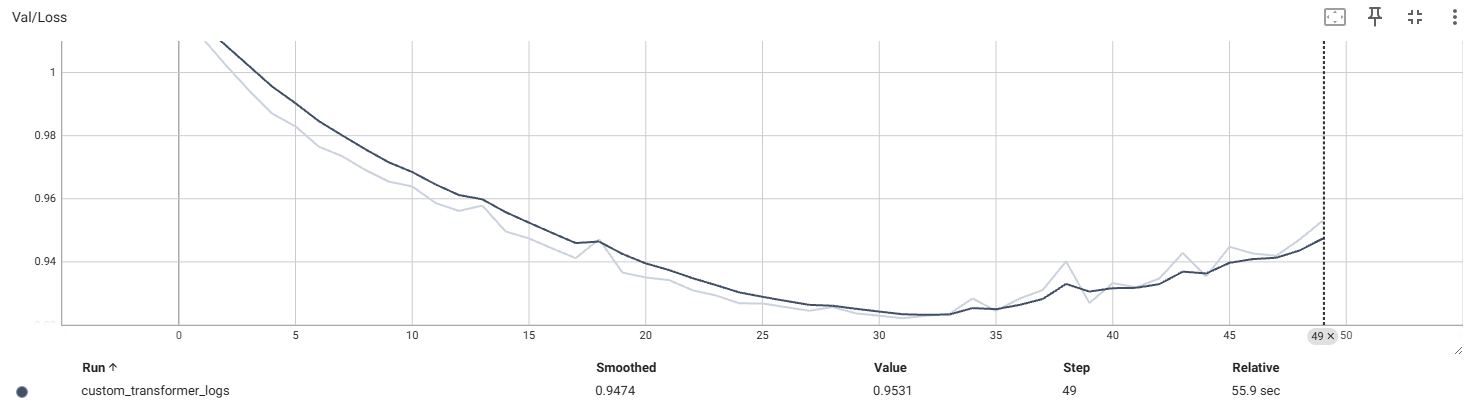

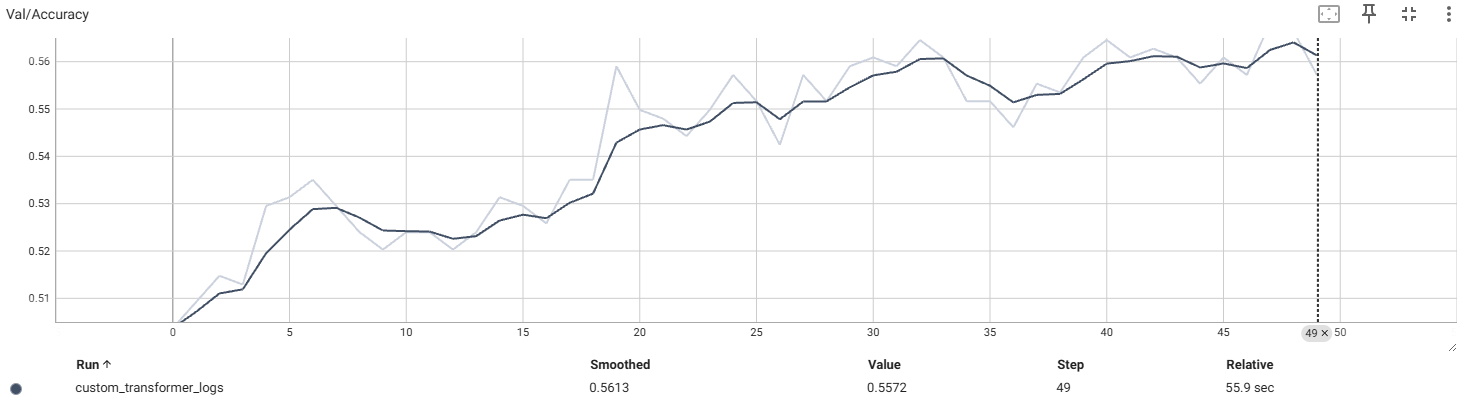

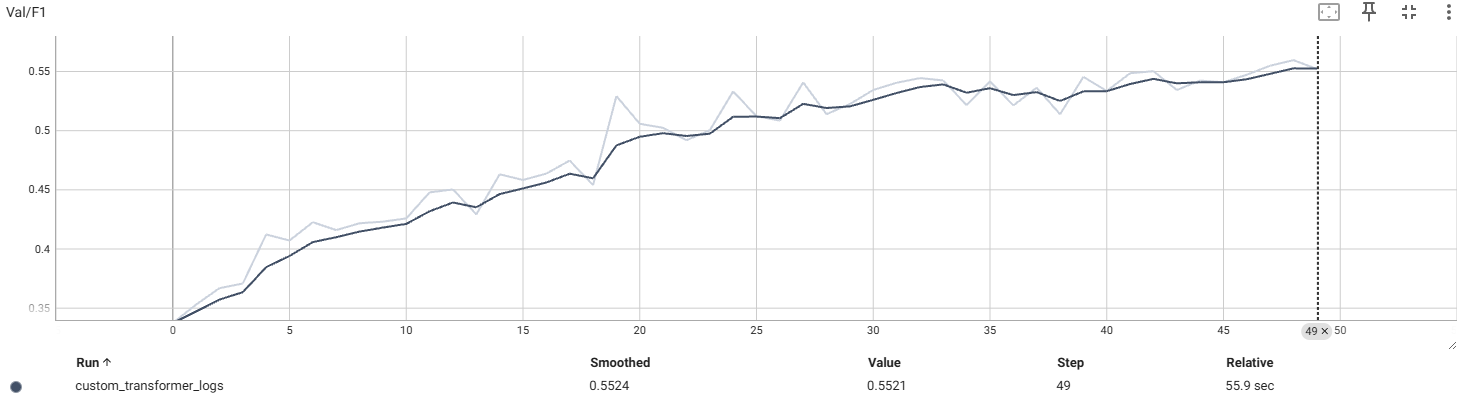

The model learned basic patterns up to Epoch 30, reaching a minimum loss of
~0.92. After this point, the validation loss began to curl upwards, while the
training loss continued to decrease. This indicates that the model began
memorizing specific training examples rather than learning general language
rules. The model hit a hard accuracy ceiling of ~56%. Given that the dataset has
3 classes, the model failed to capture the nuance of the slang. Training was
however extremely fast, just under 1 minute.

### Fine-tuned model performance

The Fine-Tuned model showed superior performance but surprisingly also suffered
from overfitting due to the small dataset size.

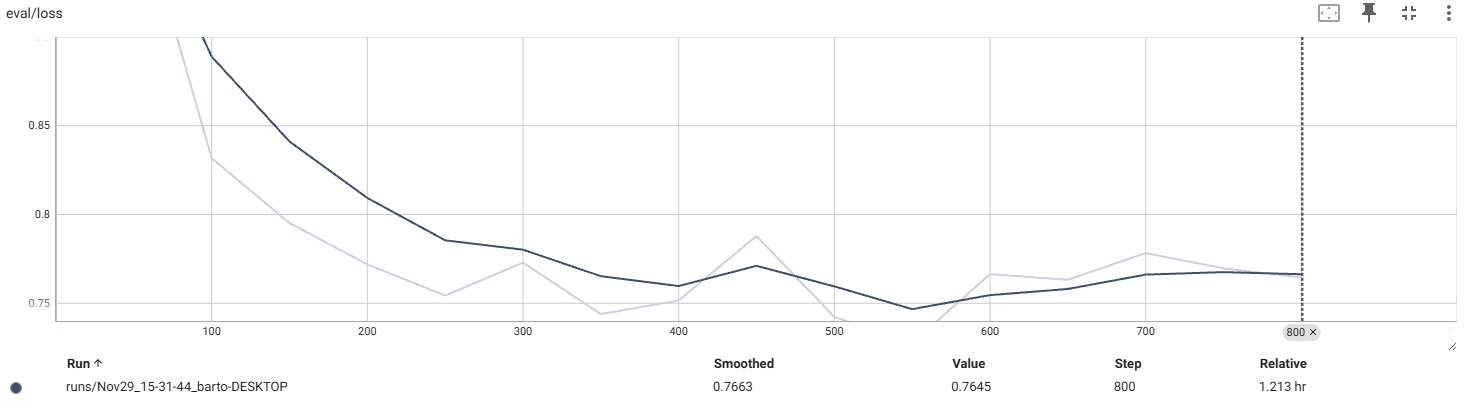

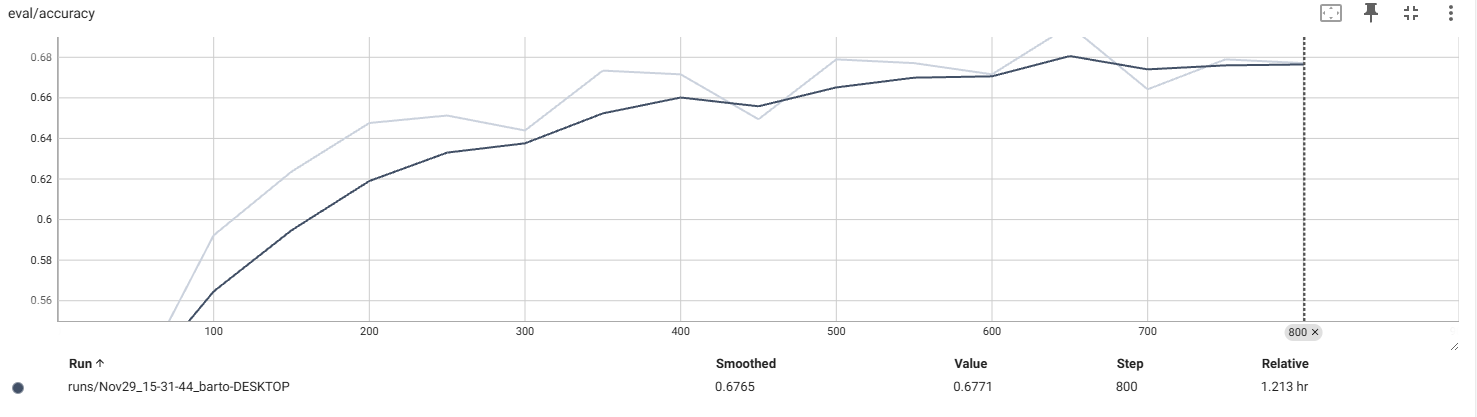

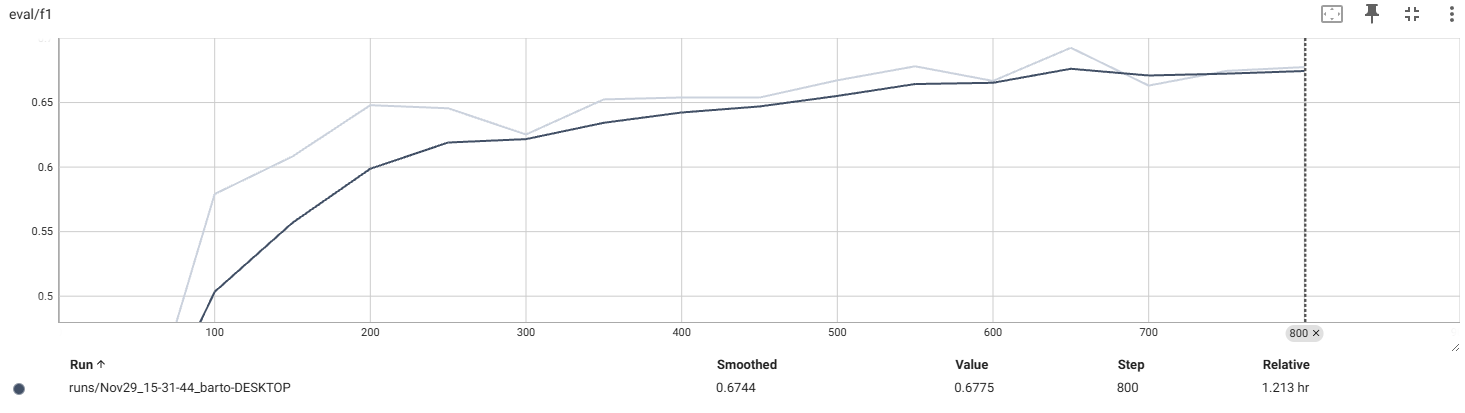

The model converged extremely fast. By Step 500 (approx. Epoch 2), it reached
its optimal performance. The model achieved a peak accuracy of 67.7% and an F1
score of 0.68. The training was however much longer (~1 hour), as we didn't
freeze any parameters and instead opted for the simplest approach of fine-tuning
the whole model.

|Metric                  |From-Scratch     |Fine-Tuned (HerBERT)|
|------------------------|-----------------|--------------------|
|Best Validation Accuracy|56.1%            |67.8%               |
|Best F1 Score           |0.55             |0.67                |
|Convergence Speed       |Slow (~30 Epochs)|Fast (~2 Epochs)    |
|Training Time           |~1 min           |~1 hour             |
|Inference Time (Batch)  |~25ms            |~180ms              |

## 5. Analysis

The Fine-Tuned model outperformed the From-Scratch model by nearly 12 percentage
points in terms of accuracy. This gap represents the "knowledge difference"
between models. HerBERT already understands Polish grammar and context. The
From-Scratch model had to learn complex linguistic rules plus the specific slang
definitions simultaneously from only 4,000 examples, which is an impossible
task.

However, the fact that HerBERT only reached 67.8% (rather than the typical >90%
seen on datasets like AG News) suggests that the slang dataset is difficult,
probably noisy, highly subjective, or contains neologisms so obscure that even
the pre-trained HerBERT embeddings could not fully capture them.

While HerBERT is more accurate, the From-Scratch model is significantly more
efficient. With only ~170K parameters, the From-Scratch model's inference is
roughly 7x faster and requires ~200x less memory. In a hypothetical scenario
where 56% accuracy is acceptable (e.g., a rough heuristic filter on an edge
device), the From-Scratch model would be the superior engineering choice.

Leveraging pre-trained weights provided a significant performance boost (+12%),
however both models overfitted rapidly. This suggest that training (or
finetuning) transformer models on small datasets is generally difficult.
Nowadays one would probably obtain better results using prompt engineering and
in-context learning capabilities of modern billion-parameter-LLMs instead of
training smaller-size models.